In [1]:
# Copyright (c) 2026 Simulacra Research Inc.
# SPDX-License-Identifier: Apache-2.0

# Learned merge-tree order for a 4×4 J1–J2 torus

The public Hamiltonian is built in textbook units. `prepare` loads HamiltonZero v1, selects the beam-8 route, compiles the wavefunction, and returns both directions of the mapping between public input sites and binary-tree leaves.

In [2]:
from pathlib import Path

import jax
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import networkx as nx
import numpy as np

from hamiltonzero import SpinHamiltonian, prepare

In [3]:
L = 4
J1 = 1.0
J2 = 0.3
nodes = tuple((row, column) for row in range(L) for column in range(L))
graph = nx.Graph()
graph.add_nodes_from(nodes)
for row, column in nodes:
    graph.add_edge((row, column), (row, (column + 1) % L), J=J1)
    graph.add_edge((row, column), ((row + 1) % L, column), J=J1)
    graph.add_edge((row, column), ((row + 1) % L, (column + 1) % L), J=J2)
    graph.add_edge((row, column), ((row + 1) % L, (column - 1) % L), J=J2)
graph.graph["needs_fwl2"] = False
system = SpinHamiltonian.from_networkx(graph, nodes=nodes)

In [4]:
route_key = jax.random.PRNGKey(0)
compiled, order = prepare(
    system,
    Path("weights/hamiltonzero_v1.eqx"),
    route_key,
)
leaf_to_input = np.asarray(order.leaf_to_input, dtype=np.int32)
input_to_leaf = np.asarray(order.input_to_leaf, dtype=np.int32)
print("leaf  input  lattice site")
for leaf, site in enumerate(leaf_to_input):
    print(f"{leaf:>4}  {site:>5}  {system.nodes[site]}")

leaf  input  lattice site
   0      0  (0, 0)
   1      1  (0, 1)
   2      2  (0, 2)
   3      3  (0, 3)
   4      7  (1, 3)
   5      6  (1, 2)
   6      5  (1, 1)
   7      4  (1, 0)
   8      8  (2, 0)
   9      9  (2, 1)
  10     10  (2, 2)
  11     11  (2, 3)
  12     15  (3, 3)
  13     14  (3, 2)
  14     13  (3, 1)
  15     12  (3, 0)


## Permutation convention

`leaf_to_input[leaf]` gives the index in `system.nodes` placed at that compiled leaf. `input_to_leaf[site]` is the inverse used below to color each public lattice site by its merge-tree cell. The NetworkX loader preserves the supplied node order. HamiltonZero applies the learned permutation once to the context and walkers, then compiles an identity-routed tree, so **no extra bit reversal is needed**. For padded systems the arrays also contain virtual leaves, which must remain when determining merge groups even though they are not drawn as physical sites.

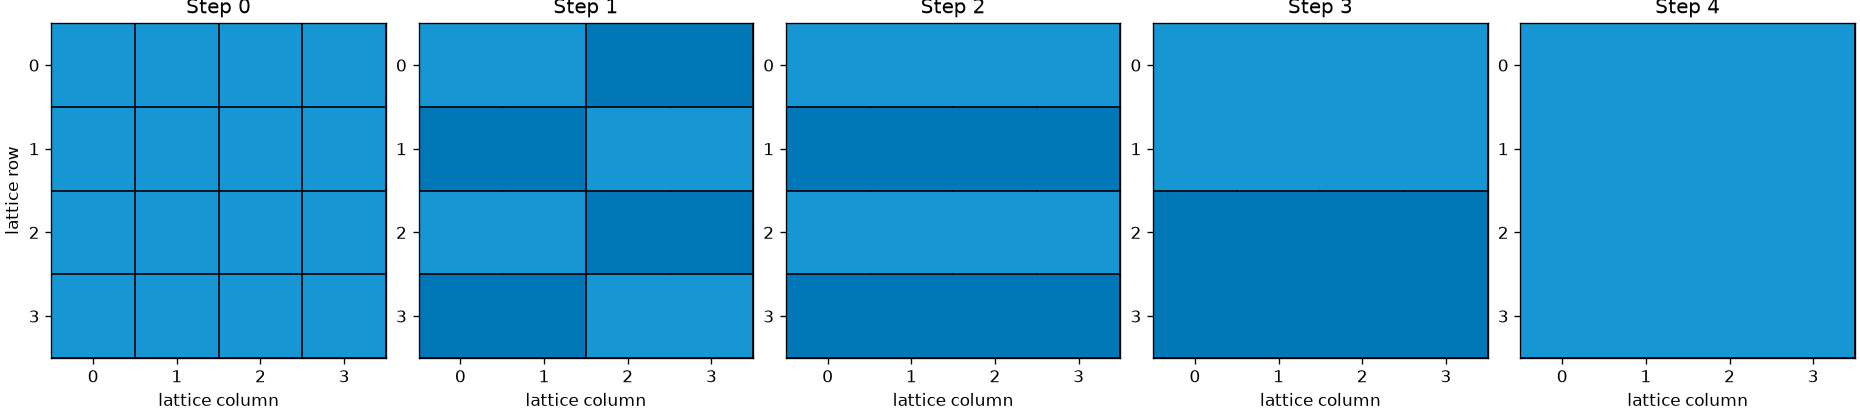

In [5]:
palette = ListedColormap([
    "#1696d2", "#0077b6", "#00a676", "#f59f00",
    "#7b2cbf", "#e76f51", "#577590", "#90be6d",
])

def color_regions(labels):
    regions = sorted(np.unique(labels))
    neighbors = {region: set() for region in regions}
    for row in range(L):
        for column in range(L):
            here = labels[row, column]
            if row + 1 < L:
                there = labels[row + 1, column]
                if here != there:
                    neighbors[here].add(there)
                    neighbors[there].add(here)
            if column + 1 < L:
                there = labels[row, column + 1]
                if here != there:
                    neighbors[here].add(there)
                    neighbors[there].add(here)
    assigned = {}
    for region in regions:
        used = {assigned[value] for value in neighbors[region] if value in assigned}
        assigned[region] = next(color for color in range(palette.N) if color not in used)
    return np.vectorize(assigned.__getitem__)(labels)

if leaf_to_input.shape != (L * L,) or not np.array_equal(np.sort(leaf_to_input), np.arange(L * L)):
    raise ValueError("the returned order is not a permutation of the 4x4 public sites")
leaf_position = input_to_leaf
levels = int(np.log2(leaf_to_input.size)) + 1
fig, axes = plt.subplots(1, levels, figsize=(3.1 * levels, 3.4), constrained_layout=True)
for level, axis in enumerate(axes):
    labels = (leaf_position // (2**level)).reshape(L, L)
    colors = np.zeros_like(labels) if level == 0 else color_regions(labels)
    axis.imshow(colors, cmap=palette, vmin=0, vmax=palette.N - 1, origin="upper")
    for boundary in range(L + 1):
        axis.plot([-0.5, L - 0.5], [boundary - 0.5, boundary - 0.5], color="black", linewidth=1.0) if boundary in (0, L) else None
        axis.plot([boundary - 0.5, boundary - 0.5], [-0.5, L - 0.5], color="black", linewidth=1.0) if boundary in (0, L) else None
    for row in range(L):
        for column in range(L - 1):
            if labels[row, column] != labels[row, column + 1]:
                axis.plot([column + 0.5, column + 0.5], [row - 0.5, row + 0.5], color="black", linewidth=1.0)
    for row in range(L - 1):
        for column in range(L):
            if labels[row, column] != labels[row + 1, column]:
                axis.plot([column - 0.5, column + 0.5], [row + 0.5, row + 0.5], color="black", linewidth=1.0)
    axis.set_title(f"Step {level}")
    axis.set_xticks(range(L))
    axis.set_yticks(range(L))
    axis.set_xlabel("lattice column")
    axis.set_ylabel("lattice row" if level == 0 else "")
plt.show()